In [ ]:
tpl = (1, 10)
print(*range(tpl))

In [1]:
import torch
from torch.utils import data
from torchvision import transforms as T

from src.dataloaders.dataloader_for_CNN import mavDataLoader, mavDatasetCNN_3D, SequenceBatchSampler
from src.normalize.PoseNormolizerLie import PoseNormalizerLie

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Обучение на:', device, sep=' ')

transform = T.Compose([
    T.Resize((320, 192))
])

normalize = PoseNormalizerLie()
normalize.load('process_of_fitting/normalize_params/params_of_normalize.json')

dataset = mavDatasetCNN_3D('datasets/euroc_mav', transform, normalize=normalize, device='cpu', batchsize=32, hidden_size=0, lst_of_datasets=['mav0_easy1']) # Сразу формируем все массивы на GPU

groups = dataset.batch_groups.copy()

train_size = int(0.8 * len(groups))
train_groups = groups[:train_size]
test_groups = groups[train_size:]


train_sampler = SequenceBatchSampler(train_groups)
test_sampler = SequenceBatchSampler(test_groups)

train_data = data.DataLoader(dataset, batch_sampler=train_sampler, num_workers=6, pin_memory=True)
test_data = data.DataLoader(dataset, batch_sampler=test_sampler, num_workers=6, pin_memory=True)

import seaborn as sns
import matplotlib.pyplot as plt

Обучение на: cuda


# Преодобработка

In [7]:
_size = int(0.8 * len(dataset.batch_groups))
indx = [i for lst in dataset.batch_groups[:_size] for i in lst]

In [10]:
mass = torch.stack([i[0] for i in dataset.lst_target])[indx]
len(mass)

29056

## Виузализация прирощения координат и углов в представлении алгебры Ли

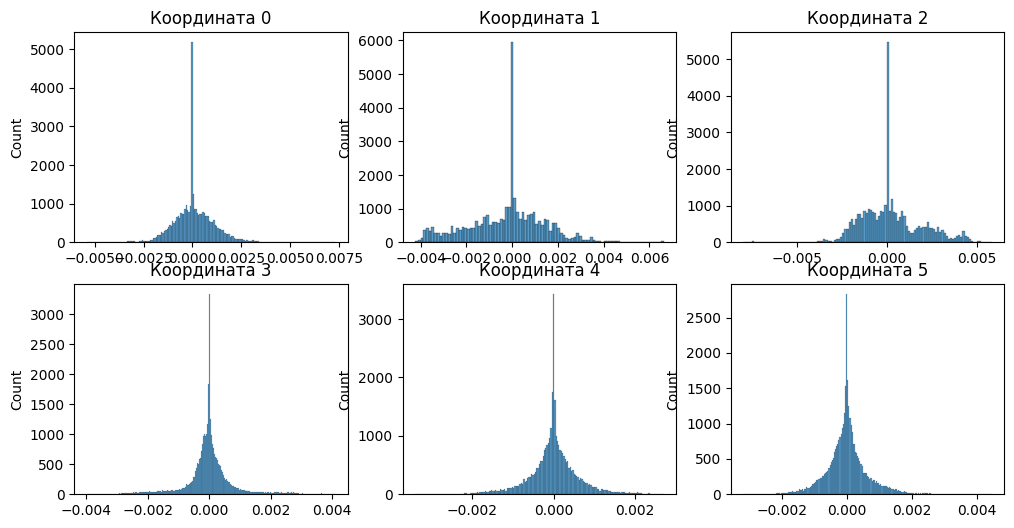

In [16]:
mass_d = normalize.denormalize(mass)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for n in range(6):
    j = n % 3
    i = 0 if n < 3 else 1
            
    sns.histplot(mass_d[..., n], ax=axes[i, j])
    axes[i, j].set_title(f'Координата {n}')
    


## Результат Z-нормализации

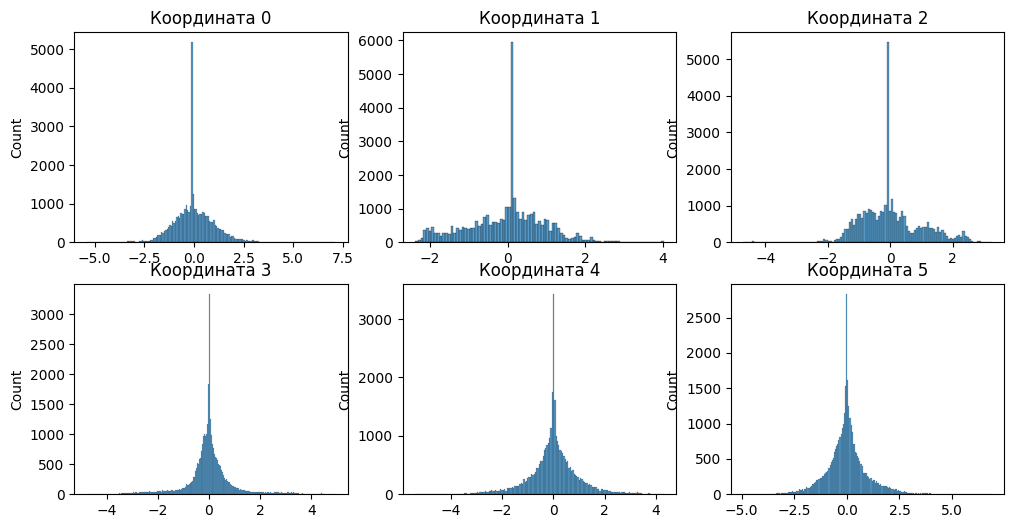

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for n in range(6):
    j = n % 3
    i = 0 if n < 3 else 1
            
    sns.histplot(mass[..., n], ax=axes[i, j])
    axes[i, j].set_title(f'Координата {n}')
    

# Тесты

In [3]:
from src.geometry.RotationTorch import RotationTorch as RT 
from src.geometry.PoseTorch import PoseTorch as PT  
from src.geometry.TrajectoryTorch import TrajectoryTorch as TT

from src.function_of_loss.mse_pose import PoseLoss, PoseLossTrajectory, PoseLoseSeq, PoseLossTrajectorySeq

In [4]:
dt = iter(train_data)
x, y, T_m = next(dt)
x2, y2, T_m2 = next(dt)
x3, y3, T_m3 = next(dt)
x4, y4, T_m4 = next(dt)

/home/wanderer/.pyenv/versions/VOP/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [5]:
loss_func = PoseLoss(reduction='mean')
loss_func(y3, y4)


tensor(276.3965, dtype=torch.float64)

In [10]:
Y = torch.stack([y, y2])
Y2 = torch.stack([y3, y4])

loss_func_2 = PoseLoseSeq()
loss_func_2(Y, Y2)

tensor(16811.2874, dtype=torch.float64)

In [ ]:
l = TT.from_lie_relative(y, PT.from_lie(T_m)[0]).path_length()
loss_func.r_loss / l, loss_func.pos_loss / l

(tensor(0.0564, dtype=torch.float64), tensor(0.0356, dtype=torch.float64))

In [13]:
T_m.shape

torch.Size([32, 6])

In [11]:
T_M = PT.from_lie(torch.stack([T_m, T_m2]))

traj = TT.from_lie_relative(normalize.denormalize(Y), T_M[0])
pred = traj[:-1]
pred

TrajectoryTorch(poses=PoseTorch(R=RotationTorch(_q=tensor([[[ 0.5341, -0.1530, -0.8274, -0.0822],
         [ 0.5346, -0.1530, -0.8270, -0.0829],
         [ 0.5352, -0.1529, -0.8266, -0.0836],
         [ 0.5357, -0.1529, -0.8261, -0.0844],
         [ 0.5362, -0.1528, -0.8257, -0.0852],
         [ 0.5368, -0.1528, -0.8253, -0.0860],
         [ 0.5373, -0.1527, -0.8249, -0.0869],
         [ 0.5378, -0.1527, -0.8245, -0.0877],
         [ 0.5383, -0.1526, -0.8241, -0.0886],
         [ 0.5388, -0.1526, -0.8237, -0.0894],
         [ 0.5393, -0.1525, -0.8232, -0.0902],
         [ 0.5398, -0.1524, -0.8228, -0.0909],
         [ 0.5404, -0.1524, -0.8224, -0.0917],
         [ 0.5409, -0.1523, -0.8220, -0.0924],
         [ 0.5414, -0.1523, -0.8216, -0.0930],
         [ 0.5420, -0.1522, -0.8212, -0.0935],
         [ 0.5425, -0.1522, -0.8208, -0.0940],
         [ 0.5431, -0.1522, -0.8204, -0.0945],
         [ 0.5437, -0.1521, -0.8199, -0.0949],
         [ 0.5443, -0.1520, -0.8195, -0.0953],
         

In [12]:
fact = PT.from_lie(torch.stack([T_m3, T_m4]))
fact.R.shape

torch.Size([2, 32])

In [13]:
pred.poses.R.shape

torch.Size([2, 32])

In [15]:
loss_traj = PoseLossTrajectory()
loss_traj(pred, fact)

tensor(15.3898, dtype=torch.float64)

In [16]:
loss_traj.r_loss, loss_traj.t_loss

(tensor(0.1340, dtype=torch.float64), tensor(1.9854, dtype=torch.float64))

In [1]:
(pred - fact) ** 2

NameError: name 'pred' is not defined

# Модели

In [2]:
from src.models.CNN_ResNet50_VO import CNN_ResNet50_VO

model = CNN_ResNet50_VO()

model.encoder

ResNet(
  (conv1): Conv2d(12, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1,

In [3]:
import torch
from torch.utils import data
from torchvision import transforms as T

from src.dataloaders.dataloader_for_CNN import mavDataLoader, mavDatasetCNN_3D, SequenceBatchSampler
from src.normalize.PoseNormolizerLie import PoseNormalizerLie

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Обучение на:', device, sep=' ')

transform = T.Compose([
    T.Resize((320, 192))
])

normalize = PoseNormalizerLie()
normalize.load('process_of_fitting/normalize_params/params_of_normalize.json')

dataset = mavDatasetCNN_3D('datasets/euroc_mav', transform, normalize=normalize, device='cpu', batchsize=1, seq_len=1000, lst_of_datasets=['mav0_easy1']) # Сразу формируем все массивы на GPU

Обучение на: cuda


In [8]:
dataset.batch_groups

[[0],
 [1],
 [2],
 [3],
 [4],
 [5],
 [6],
 [7],
 [8],
 [9],
 [10],
 [11],
 [12],
 [13],
 [14],
 [15],
 [16],
 [17],
 [18],
 [19],
 [20],
 [21],
 [22],
 [23],
 [24],
 [25],
 [26],
 [27],
 [28],
 [29],
 [30],
 [31],
 [32],
 [33],
 [34],
 [35],
 [36],
 [37],
 [38],
 [39],
 [40],
 [41],
 [42],
 [43],
 [44],
 [45],
 [46],
 [47],
 [48],
 [49],
 [50],
 [51],
 [52],
 [53],
 [54],
 [55],
 [56],
 [57],
 [58],
 [59],
 [60],
 [61],
 [62],
 [63],
 [64],
 [65],
 [66],
 [67],
 [68],
 [69],
 [70],
 [71],
 [72],
 [73],
 [74],
 [75],
 [76],
 [77],
 [78],
 [79],
 [80],
 [81],
 [82],
 [83],
 [84],
 [85],
 [86],
 [87],
 [88],
 [89],
 [90],
 [91],
 [92],
 [93],
 [94],
 [95],
 [96],
 [97],
 [98],
 [99],
 [100],
 [101],
 [102],
 [103],
 [104],
 [105],
 [106],
 [107],
 [108],
 [109],
 [110],
 [111],
 [112],
 [113],
 [114],
 [115],
 [116],
 [117],
 [118],
 [119],
 [120],
 [121],
 [122],
 [123],
 [124],
 [125],
 [126],
 [127],
 [128],
 [129],
 [130],
 [131],
 [132],
 [133],
 [134],
 [135],
 [136],
 [137],
 [138]